In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 14

In [2]:
def BC_99(Teff, FeH):
    X = np.log10(Teff) - 3.52
    return -9.93e-2/X +2.887e-2 + 2.275*X - 4.425*X**2 + 0.3505*X*FeH - 5.558e-2*FeH - 5.375e-3*FeH**2

In [3]:
Y25 = pd.read_csv('../../data/M22-with-abundances.csv', dtype={'Gaia_source_ID_DR3':str})
pbjam = pd.read_csv('../../data/pbjam-results-dnu-numax-maddy-all.csv')
cross = pbjam.merge(Y25, on = 'star_id')


In [4]:
logL = np.log10(cross['Lum_bol'])
BC99 = BC_99(cross['Teff_final'], -1.1)

In [5]:
logg = np.log10(cross['numax_pbjam']/3090*(cross['Teff_final']/5777)**0.5) + 4.4

In [6]:
BCT = pd.DataFrame(columns = ['star ID', 'logg', '[Fe/H]', 'Teff', 'E(B-V)'])
BCT['star ID'] = cross['star_id']
BCT['logg'] = logg
BCT['[Fe/H]'] = -1.07*np.ones_like(logg)
BCT['Teff'] = cross['Teff_final']
BCT['E(B-V)'] = 0*np.ones_like(logg)

In [7]:
BCT.to_csv('../../bolometric-corrections-master/BCcodes/input.sample.all', header = None, index = False, sep = ' ')

In [8]:
BC14 = pd.read_csv('../../bolometric-corrections-master/BCcodes/output.file.all', sep = '\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2524296/1100271210.py:1: SyntaxWarning: invalid escape sequence '\s'
  BC14 = pd.read_csv('../../bolometric-corrections-master/BCcodes/output.file.all', sep = '\s+')


Text(0, 0.5, 'BC$_{14}$ - BC$_{99}$')

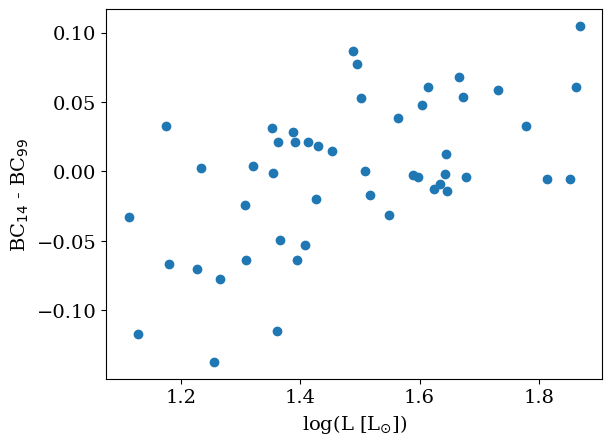

In [9]:
plt.scatter(logL, BC14['BC_1'] - BC99)
plt.xlabel(r'log(L [L$_{\odot}$])')
plt.ylabel(r'BC$_{14}$ - BC$_{99}$')

In [10]:
logl = logL+ 0.4*BC99
logL14 = logl -0.4*BC14['BC_1']
L14 = 10**logL14

caseA = cross['Lum_bol']
caseC = L14
caseB = 10**(logL - 0.4*0.14)
caseD  = 10**(logL14 - 0.4*0.14)

In [20]:
np.max(np.abs((caseB-caseD)/caseD))

np.float64(0.11871116831622149)

In [21]:
np.max(np.abs((caseC-caseD)/caseD))

np.float64(0.13762728582343114)

Text(0, 0.5, 'Count')

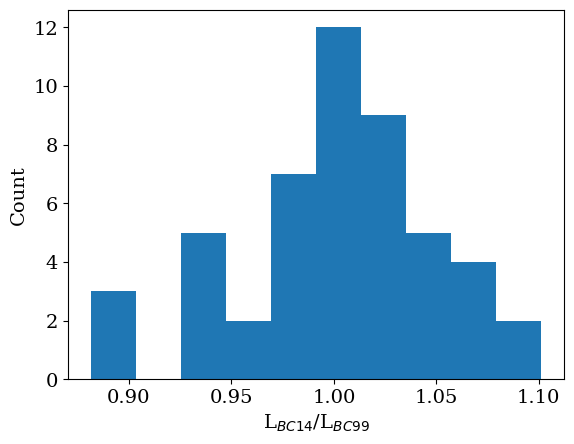

In [19]:
plt.hist(caseB/caseD)
plt.xlabel(r'L$_{BC 14}$/L$_{BC 99}$')
plt.ylabel('Count')

In [12]:
np.std(caseC/cross['Lum_bol'])

np.float64(0.04881377379267004)

Text(0, 0.5, 'Difference [%]')

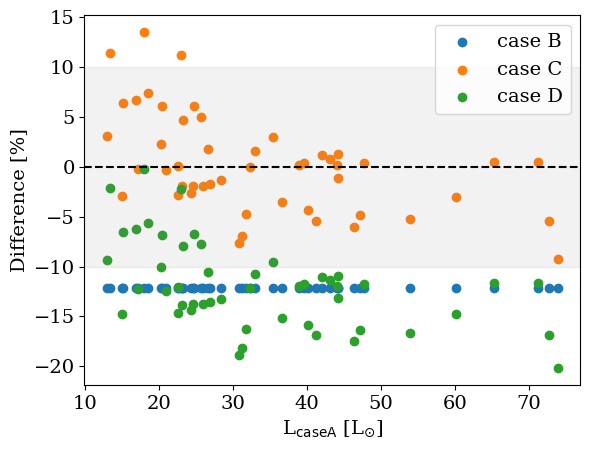

In [12]:
ax = plt.gca()
plt.scatter(caseA, 100*(caseB - caseA)/caseA, label = 'case B')
plt.scatter(caseA, 100*(caseC - caseA)/caseA, label = 'case C')
plt.scatter(caseA, 100*(caseD - caseA)/caseA, label = 'case D')
plt.axhline(0, color = 'black', linestyle = '--')
ax.axhspan(-10, 10, color = 'grey', alpha = 0.1)
plt.legend()
plt.xlabel(r'L$_{\mathrm{case A}}$ [L$_{\odot}$]')
plt.ylabel('Difference [%]')

Text(0, 0.5, 'L$_{\\mathrm{Phot}}$ [L$_{\\odot}$]')

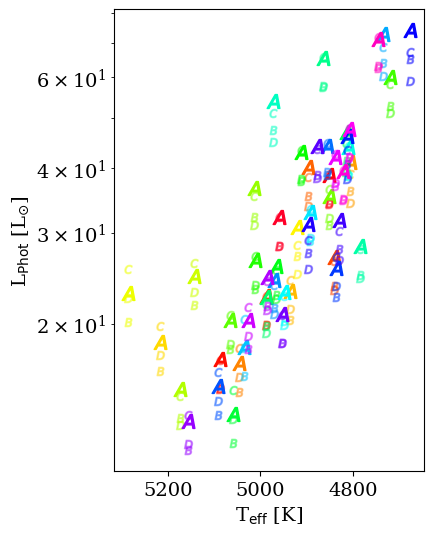

In [23]:
import matplotlib.cm as cm

fig = plt.figure(figsize = (4, 6))

colors = cm.gist_rainbow(np.linspace(0, 1, len(cross)))

ax = plt.gca()
for i in range(len(cross)):
    plt.scatter(cross.loc[i, 'Teff_final'], caseA[i], marker = '$A$', color = colors[i],s = 100)
    plt.scatter(cross.loc[i, 'Teff_final'], caseB[i], marker = '$B$', color = colors[i], alpha = 0.4)
    plt.scatter(cross.loc[i, 'Teff_final'], caseC[i], marker = '$C$', color = colors[i], alpha = 0.4)
    plt.scatter(cross.loc[i, 'Teff_final'], caseD[i], marker = '$D$', color = colors[i], alpha = 0.4)
plt.semilogy()
ax.invert_xaxis()
plt.xlabel(r'T$_{\mathrm{eff}}$ [K]')
plt.ylabel(r'L$_{\mathrm{Phot}}$ [L$_{\odot}$]')

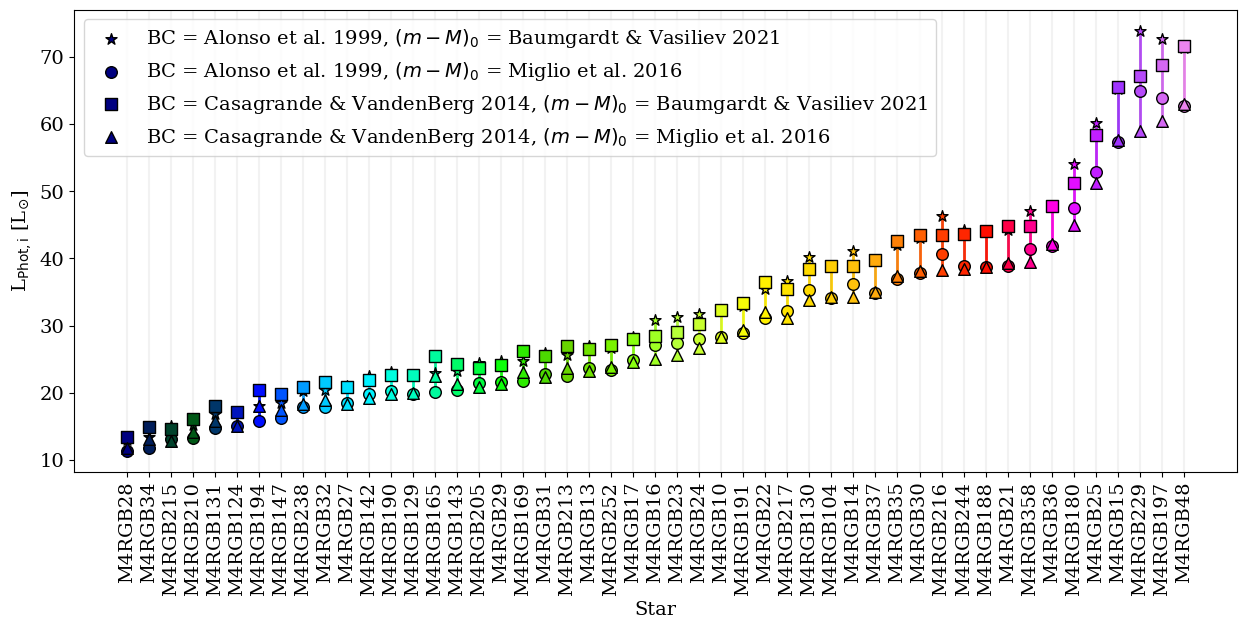

In [24]:
fig = plt.figure(figsize = (15, 6))
ax = plt.gca()
colors = cm.gist_ncar(np.linspace(0, 0.9, len(cross)))
markers = ['*', 'o', 's', '^']
labels = [r'BC = Alonso et al. 1999, $(m-M)_{0}$ = Baumgardt & Vasiliev 2021', 'BC = Alonso et al. 1999, $(m-M)_{0}$ = Miglio et al. 2016', 'BC = Casagrande & VandenBerg 2014, $(m-M)_{0}$ = Baumgardt & Vasiliev 2021', 'BC = Casagrande & VandenBerg 2014, $(m-M)_{0}$ = Miglio et al. 2016']

cross['LPhot_caseA'] = caseA
cross['LPhot_caseB'] = caseB
cross['LPhot_caseC'] = caseC
cross['LPhot_caseD'] = caseD

cross['min_L'] = cross[['LPhot_caseA', 'LPhot_caseB', 'LPhot_caseC', 'LPhot_caseD']].min(axis = 1)

cross = cross.sort_values(by='min_L').reset_index()
for i in range(len(cross)):
    ID = cross.loc[i, 'star_id']
    color = colors[i]
    cases = np.array([cross['LPhot_caseA'].loc[i], cross['LPhot_caseB'].loc[i], cross['LPhot_caseC'].loc[i], cross['LPhot_caseD'].loc[i]])

    min_y = np.min(cases)
    max_y =  np.max(cases)

    plt.vlines(ID, ymin = min_y, ymax = max_y, color = color, zorder = 0, linewidth = 2)

    for j in range(len(cases)):
        if i == 0:
            label = labels[j]
        else:
            label = None
        plt.scatter(ID, cases[j], marker = markers[j], color = color, edgecolor = 'black', zorder = 100, s = 70, label = label)

    plt.axvline(ID, color = 'grey', alpha = 0.1)
    
plt.legend()    
plt.xticks(rotation=90)
plt.xlabel('Star')
plt.ylabel(r'L$_{\mathrm{Phot, i}}$ [L$_{\odot}$]')
plt.savefig('../../figs/luminosity-comparison.png', bbox_inches = 'tight', dpi = 150)
plt.show()

In [102]:


cross.to_csv('../../data/M4_obs_Howell_pbjam_lum_vary.csv', index = False)

In [182]:
cross.loc[0]

level_0                                    42
index                                      46
star_id                               M4RGB36
dnu_pbjam                            4.557216
ednu_pbjam                           0.012291
numax_pbjam                         41.494082
enumax_pbjam                         0.325816
evol_stage                                RGB
Gaia_source_ID_DR3        6045489901650196864
2MASS_ID                     16235300-2628065
Gmag                                    13.02
Quality_flag                                D
numax_pyMon                         34.241812
numax_err_pyMon                      1.421874
Teff_final                               4808
Teff_err_final                           60.0
Lum_bol                                 47.67
Lum_bol_err_random                       0.97
Lum_bol_err_systematic                   5.54
Mass                                      1.0
Mass_err_rand                            0.06
[Fe/HI]                           